# Notebook 02 — Storytelling executivo e análise não supervisionada

Notebook para gerar gráficos de clusters, drivers, drift e sensibilidade econômica.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
REPORTS = PROJECT_ROOT / "reports"

cluster_profile = pd.read_csv(REPORTS / "unsup_cluster_profile.csv")
drivers = pd.read_csv(REPORTS / "unsup_cluster_drivers.csv")
drift = pd.read_csv(REPORTS / "unsup_monthly_drift.csv")
best_policy = pd.read_csv(REPORTS / "best_policy_by_accept_free.csv")
cluster_profile.head()

,cluster,rows,p_churn,churn_3m,fp,fn,paid_sum,total_secs,num_unq,auto_renew_rate,cancel_txn_count,share
0,3,174630,0.366724,0.049957,0.428243,0.043332,264.784768,123362.455737,487.535996,0.505669,0.010754,0.058448
1,1,409798,0.146694,0.203017,0.069844,0.184928,0.106535,124637.621513,492.353096,0.234631,0.008237,0.137157
2,0,138703,0.083090,0.062421,0.070287,0.054238,146.312345,749605.923697,2402.255719,0.857771,0.008215,0.046423
3,2,251960,0.048132,0.039105,0.032918,0.036212,140.158352,246403.353383,900.677627,0.870262,0.010848,0.084330
4,4,611424,0.026980,0.036250,0.013851,0.034462,143.272626,204657.365621,784.354546,0.712479,0.010010,0.204641


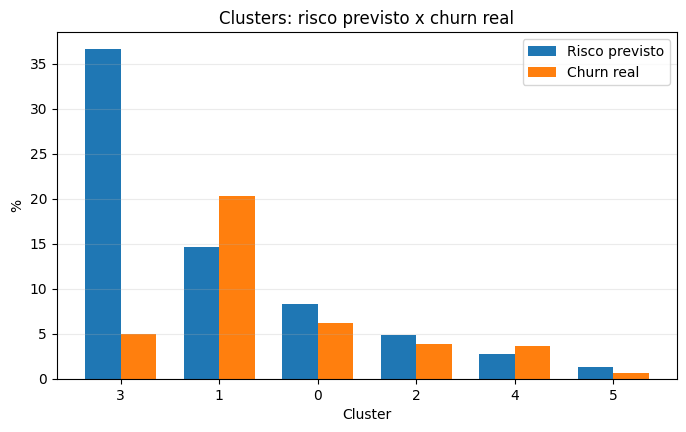

In [2]:
plt.figure(figsize=(8,4.5))
x = range(len(cluster_profile))
plt.bar([i-0.18 for i in x], cluster_profile["p_churn"]*100, width=0.36, label="Risco previsto")
plt.bar([i+0.18 for i in x], cluster_profile["churn_3m"]*100, width=0.36, label="Churn real")
plt.xticks(list(x), cluster_profile["cluster"])
plt.xlabel("Cluster")
plt.ylabel("%")
plt.title("Clusters: risco previsto x churn real")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.show()

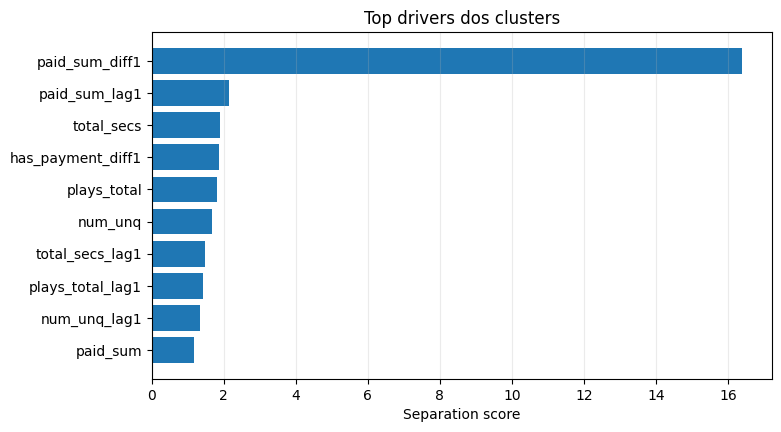

In [3]:
top_drivers = drivers.head(10).copy().sort_values("separation_score")
plt.figure(figsize=(8,4.5))
plt.barh(top_drivers["feature"], top_drivers["separation_score"])
plt.xlabel("Separation score")
plt.title("Top drivers dos clusters")
plt.grid(axis="x", alpha=0.25)
plt.show()

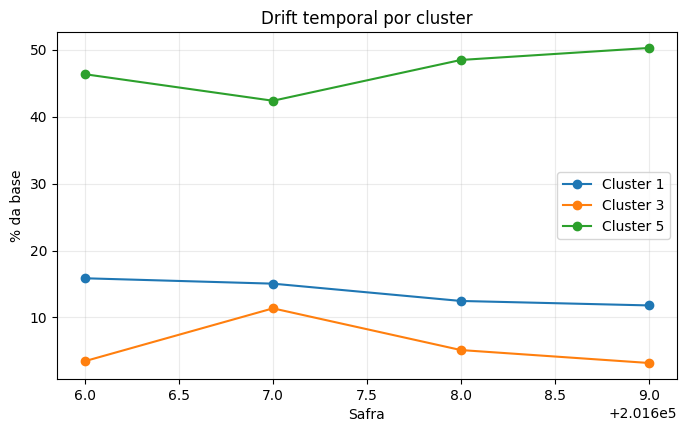

In [4]:
focus = drift[drift["cluster"].isin([1,3,5])].copy()
plt.figure(figsize=(8,4.5))
for c in sorted(focus["cluster"].unique()):
    d = focus[focus["cluster"] == c]
    plt.plot(d["safra"], d["share"]*100, marker="o", label=f"Cluster {c}")
plt.xlabel("Safra")
plt.ylabel("% da base")
plt.title("Drift temporal por cluster")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

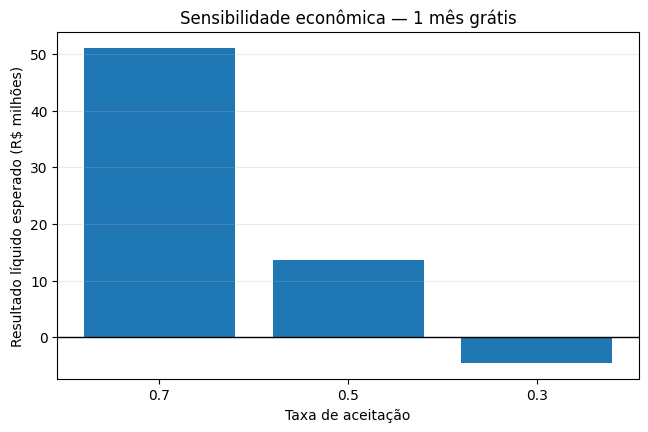

In [5]:
bp = best_policy[best_policy["free_months"] == 1].copy()
plt.figure(figsize=(7.5,4.5))
plt.bar(bp["accept_rate"].astype(str), bp["expected_net"]/1e6)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Taxa de aceitação")
plt.ylabel("Resultado líquido esperado (R$ milhões)")
plt.title("Sensibilidade econômica — 1 mês grátis")
plt.grid(axis="y", alpha=0.25)
plt.show()

## Leituras executivas sugeridas

- Cluster 1: maior churn real, principal público de retenção.
- Cluster 3: falso-alarme do modelo, importante para recalibração.
- Cluster 5: base saudável, baixo risco e alta taxa de auto-renew.
- Conclusão econômica: 3 meses grátis tende a ser deficitário; 1 mês grátis torna a política mais viável.